# Cloud Computing and Big Data Project: Benchmark Analysis
### Variant 5 — Manifest-based publishing (safe dataset versioning)

This notebook analyses the results of a cloud data lake benchmarking study comparing object storage performance across Amazon S3 and Azure Blob Storage. It evaluates upload, download, query and publishing workloads across multiple dataset sizes (S, M, L) and scan query patterns, using repeated measurements to ensure statistical stability.

## 1. Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# ── Global Style: "Life of a Showgirl" ────────────────────────────────────
plt.rcParams.update({
    # figure
    'figure.dpi': 130,
    'figure.facecolor': 'white',

    # axes
    'axes.facecolor': 'white',
    'axes.edgecolor': '#E6B7C8',
    'axes.grid': True,

    # grid
    'grid.color': '#F7D6E0',
    'grid.linewidth': 0.8,
    'grid.alpha': 0.7,

    # typography
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,

    # ticks
    'xtick.color': '#444444',
    'ytick.color': '#444444',
})

# compatibility for older matplotlib
colormaps = getattr(mpl, "colormaps", None)

# ── Showgirl palette ──────────────────────────────────────────────────────
PALETTE = {
    'spotlight': '#FFD166',   # warm stage gold
    'velvet':    '#8B1E3F',   # deep theatrical red
    'glitter':   '#F4A7B9',   # soft pink shimmer
    'midnight':  '#1B1B3A',   # backstage navy
    'applause':  '#EC4D25',   # loud emotional orange-red
    'haze':      '#71B6AF',   # dreamy blue-green haze
}

# backend colors
COLORS = {
    's3': PALETTE['applause'],
    'azure': PALETTE['haze'],
}

SIZE_ORDER = ['S', 'M', 'L']

SIZE_LABELS = {
    'S': 'S\n(~1 GB)',
    'M': 'M\n(~5 GB)',
    'L': 'L\n(~10 GB)'
}

SIZE_COLORS = {
    'S': PALETTE['glitter'],
    'M': PALETTE['spotlight'],
    'L': PALETTE['midnight']
}

PRESET_DESC = {
    'v1': 'region+date\n(H1 1812)',
    'v2': 'event+date\n(H2 1812)',
    'v3': 'character\n+region',
    'v4': 'mood+event\n(high sel.)',
    'v5': 'date only\n(6 months)',
    'v6': 'region\nonly',
    'v7': 'event\nonly',
}

In [27]:
df = pd.read_csv("results.csv")


In [28]:
def grouped_bars(ax, df, test_type, metric, title, ylabel):
    sub = df[df['test_type'] == test_type]

    backends = sorted(sub['backend'].unique())
    sizes = [s for s in SIZE_ORDER if s in sub['size_label'].values]

    x = np.arange(len(sizes))
    n = len(backends)

    width = 0.35
    offsets = np.linspace(-(n - 1) * width / 2, (n - 1) * width / 2, n)

    for i, backend in enumerate(backends):
        bsub = sub[sub['backend'] == backend].groupby('size_label')[metric].agg(['mean', 'std'])

        means = [bsub.loc[s, 'mean'] if s in bsub.index else np.nan for s in sizes]
        stds  = [bsub.loc[s, 'std'] if s in bsub.index else 0 for s in sizes]

        color = COLORS.get(backend, PALETTE['glitter'])

        bars = ax.bar(
            x + offsets[i],
            means,
            width * 0.9,
            label=str(backend).upper(),
            color=color,
            yerr=stds,
            capsize=4,
            error_kw={'lw': 1.2}
        )

        for bar, m in zip(bars, means):
            if not np.isnan(m):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 1.02,
                    f'{m:.1f}',
                    ha='center',
                    va='bottom',
                    fontsize=8
                )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels([SIZE_LABELS[s] for s in sizes])
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)

## 2. Upload/Download time

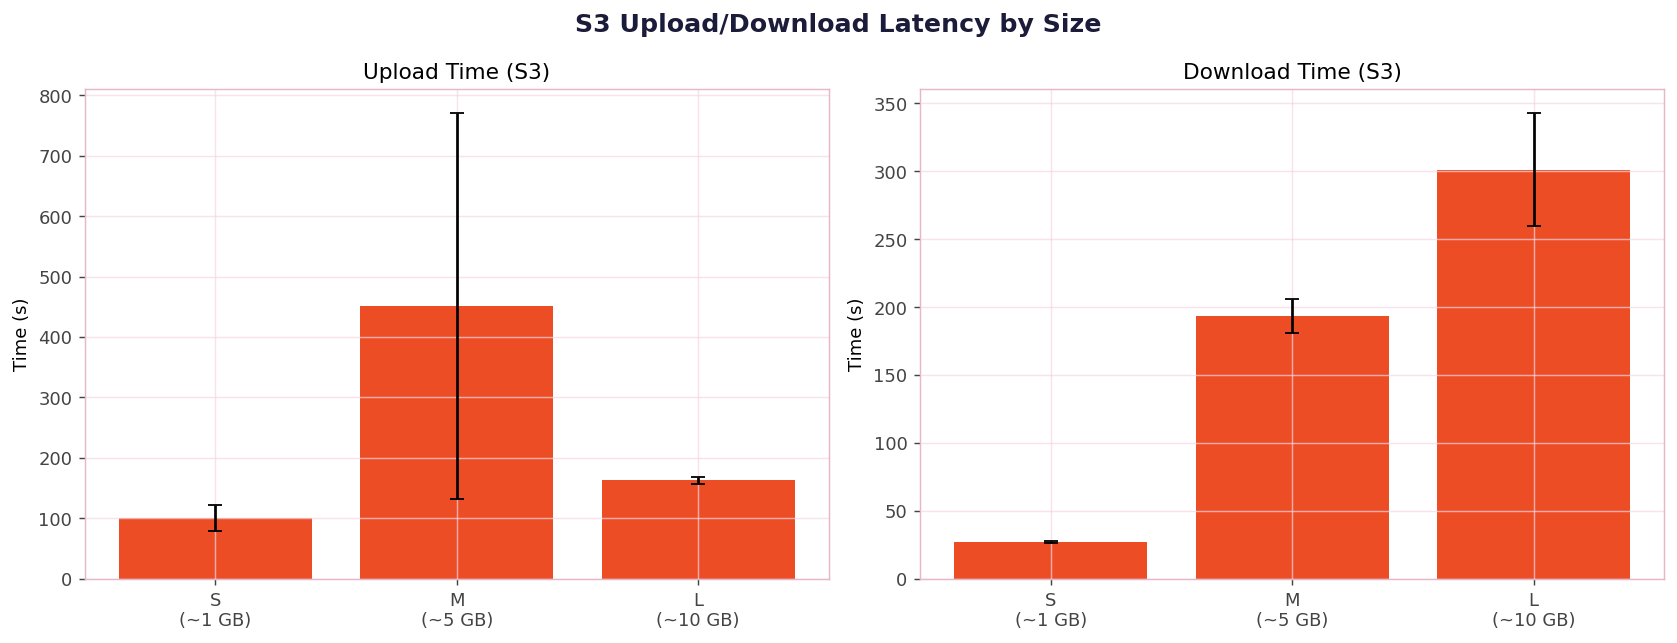

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Upload ─────────────────────────────────────────────
upload = df[(df['test_type'] == 'upload') & (df['backend'] == 's3')]

u = (
  upload.groupby('size_label')['elapsed_ms'].agg(['mean', 'std']).reindex(SIZE_ORDER)
  / 1000 # convert from ms to s
)

x = np.arange(len(u))

axes[0].bar(
    x,
    u['mean'],
    yerr=u['std'],
    capsize=4,
    color=COLORS['s3']
)

axes[0].set_xticks(x)
axes[0].set_xticklabels([SIZE_LABELS[s] for s in u.index])
axes[0].set_title('Upload Time (S3)')
axes[0].set_ylabel('Time (s)')
axes[0].set_facecolor("white")
axes[0].grid(True, color="#F7D6E0", linewidth=0.8)

# ── Download ───────────────────────────────────────────
download = df[(df['test_type'] == 'download') & (df['backend'] == 's3')]

d = (
  download.groupby('size_label')['elapsed_ms'].agg(['mean', 'std']).reindex(SIZE_ORDER)
  / 1000
)

x = np.arange(len(d))

axes[1].bar(
    x,
    d['mean'],
    yerr=d['std'],
    capsize=4,
    color=COLORS['s3']
)

axes[1].set_xticks(x)
axes[1].set_xticklabels([SIZE_LABELS[s] for s in d.index])
axes[1].set_title('Download Time (S3)')
axes[1].set_ylabel('Time (s)')
axes[1].set_facecolor("white")
axes[1].grid(True, color="#F7D6E0", linewidth=0.8)

# ── Global title ───────────────────────────────────────
fig.suptitle(
    'S3 Upload/Download Latency by Size',
    fontsize=14,
    fontweight='bold',
    color=PALETTE['midnight']
)

plt.tight_layout()
plt.show()

## 3. Warmup Effect

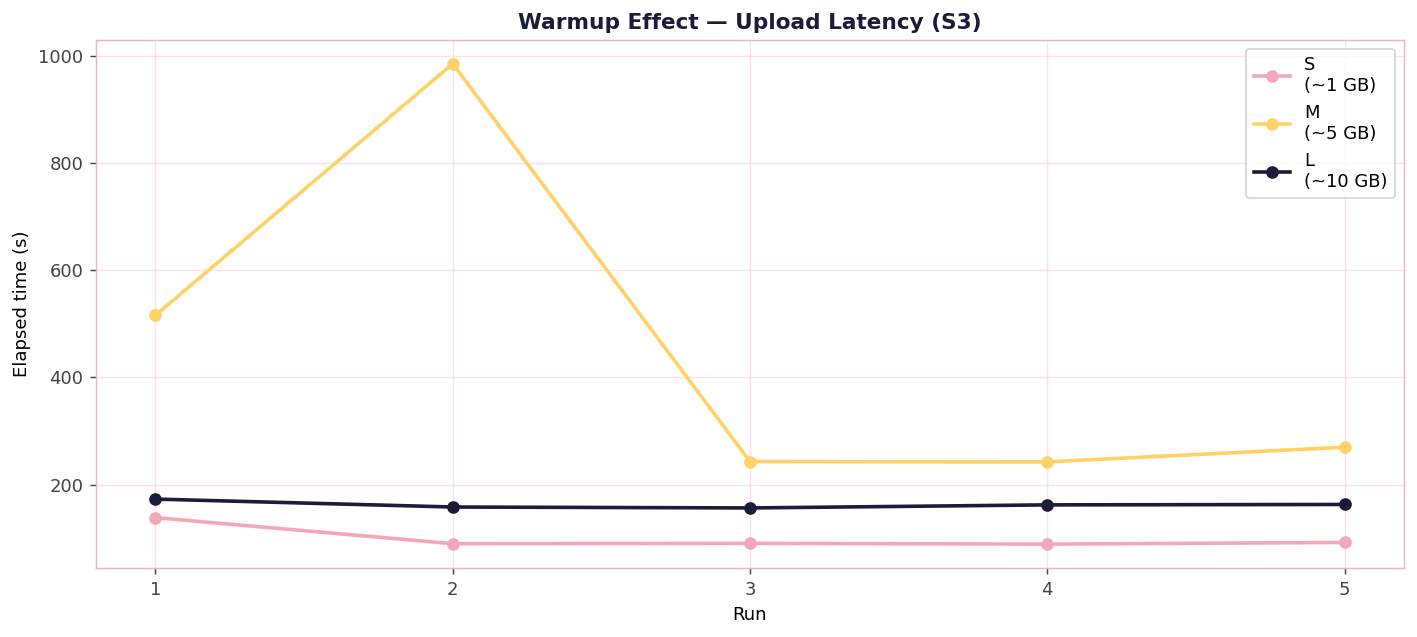

In [46]:
fig, ax = plt.subplots(figsize=(11, 5))

sub = df[(df['test_type'] == 'upload') & (df['backend'] == 's3')]

for size in SIZE_ORDER:
    ssub = sub[sub['size_label'] == size].reset_index(drop=True)

    if len(ssub) == 0:
        continue

    ssub['elapsed_s'] = ssub['elapsed_ms'] / 1000
    
    runs = np.arange(1, len(ssub) + 1)
    
    ax.plot(
        runs,
        ssub['elapsed_s'],
        marker='o',
        linewidth=2,
        label=SIZE_LABELS[size],
        color=SIZE_COLORS[size]
    )

ax.set_title('Warmup Effect — Upload Latency (S3)', fontweight='bold', color=PALETTE['midnight'])
ax.set_xlabel('Run')
ax.set_ylabel('Elapsed time (s)')

ax.set_facecolor("white")
ax.grid(True, color="#F7D6E0", linewidth=0.8)

ax.legend()

# Use integers for run numbers
from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## 4. Listing Overhead

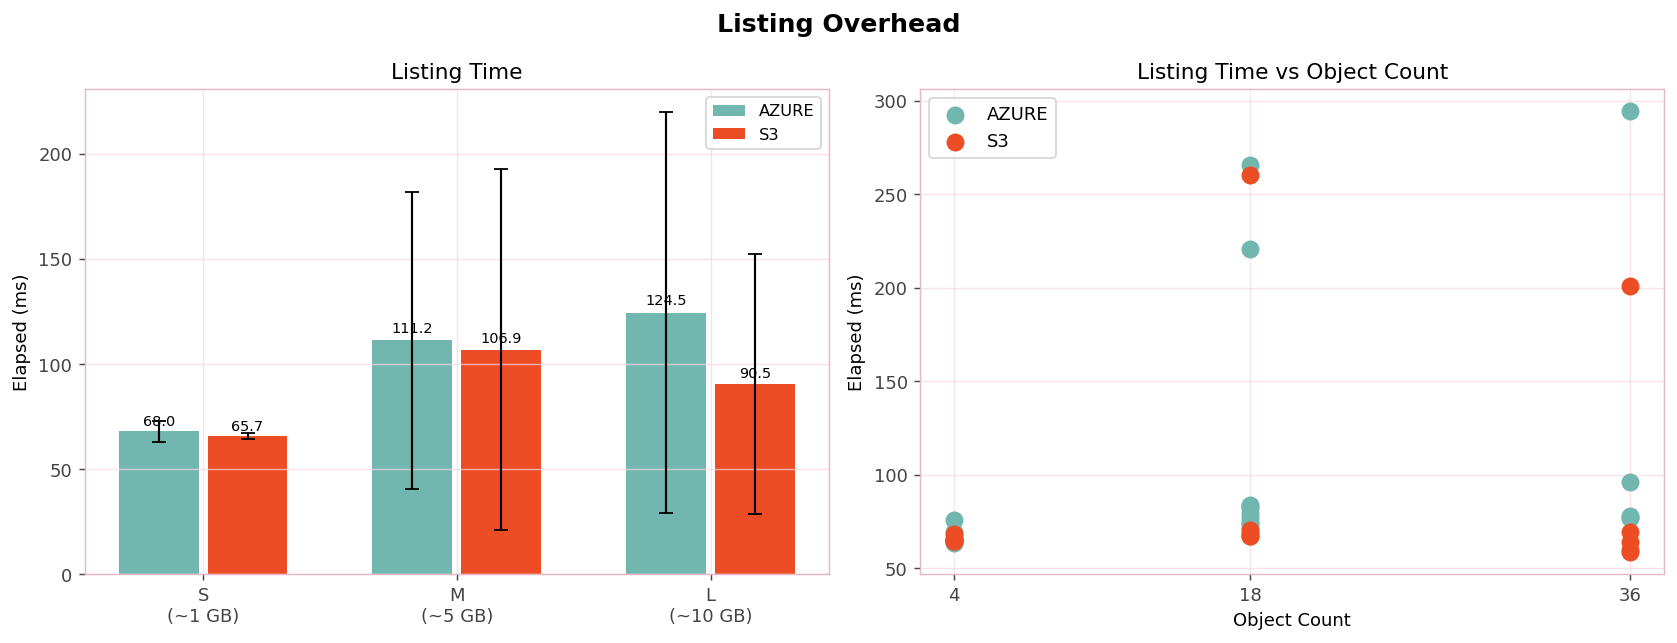

mean_elapsed_ms  std_elapsed_ms  object_count  \
backend size_label                                                  
azure   L                    124.50           95.23            36   
        M                    111.21           70.47            18   
        S                     67.95            5.04             4   
s3      L                     90.46           61.78            36   
        M                    106.86           85.87            18   
        S                     65.65            1.58             4   

                    list_requests  
backend size_label                 
azure   L                     1.0  
        M                     1.0  
        S                     1.0  
s3      L                     1.0  
        M                     1.0  
        S                     1.0

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
grouped_bars(axes[0], df, 'listing', 'elapsed_ms', 'Listing Time', 'Elapsed (ms)')

listing_df = df[df['test_type']=='listing'].dropna(subset=['object_count','elapsed_ms'])
for backend, grp in listing_df.groupby('backend'):
    axes[1].scatter(grp['object_count'], grp['elapsed_ms'],
                    label=backend.upper(), color=COLORS[backend], s=80, zorder=3)
axes[1].set_xlabel('Object Count'); axes[1].set_ylabel('Elapsed (ms)')
axes[1].set_title('Listing Time vs Object Count'); axes[1].legend()
axes[1].set_xticks(sorted(listing_df['object_count'].unique()))

fig.suptitle('Listing Overhead', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

df[df['test_type']=='listing'].groupby(['backend','size_label']).agg(
    mean_elapsed_ms=('elapsed_ms','mean'),
    std_elapsed_ms=('elapsed_ms','std'),
    object_count=('object_count','first'),
    list_requests=('list_requests','first'),
).round(2)

## 5. Parquet Scan — Query Performance & Predicate Pushdown

We ran 7 query presets with different filter combinations to study how Parquet's predicate pushdown affects scan time.

| Preset | Filters |
|--------|--------|
| v1 | region=Pemberley + date H1 1812 |
| v2 | event=ball_attendance + date H2 1812 |
| v3 | character=Mr. Darcy + region=Pemberley |
| v4 | mood=mortified + event=proposal_rejected (high selectivity) |
| v5 | date range only (6 months) |
| v6 | region=Longbourn only |
| v7 | event=dramatic_hand_flex only |

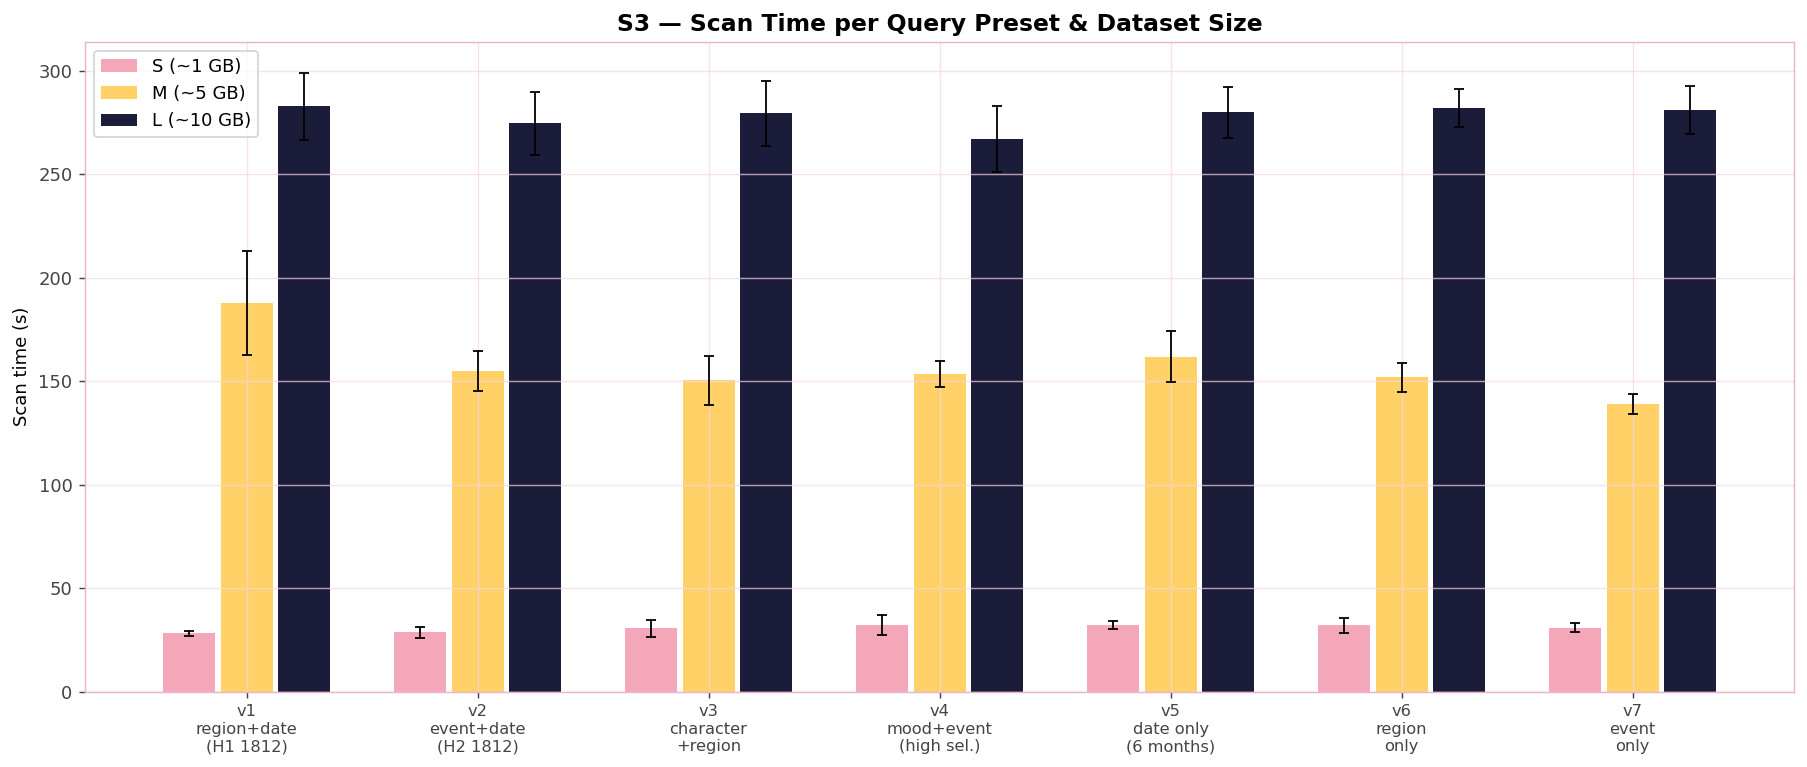

In [32]:
scan_df = df[df['test_type'].str.startswith('scan/')].copy()
scan_df['preset'] = scan_df['test_type'].str.replace('scan/', '')
s3_scan = scan_df[scan_df['backend'] == 's3']
presets = sorted(s3_scan['preset'].unique())
sizes_present = [s for s in SIZE_ORDER if s in s3_scan['size_label'].values]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(presets))
width = 0.25
offsets = np.linspace(-(len(sizes_present)-1)*width/2, (len(sizes_present)-1)*width/2, len(sizes_present))

for i, size in enumerate(sizes_present):
    sub = s3_scan[s3_scan['size_label']==size].groupby('preset')['scan_ms'].agg(['mean','std']) / 1000
    means = [sub.loc[p,'mean'] if p in sub.index else np.nan for p in presets]
    stds  = [sub.loc[p,'std']  if p in sub.index else 0      for p in presets]
    ax.bar(x+offsets[i], means, width*0.9, label=SIZE_LABELS[size].replace('\n',' '),
           color=SIZE_COLORS[size], yerr=stds, capsize=3, error_kw={'lw':1})

ax.set_title('S3 — Scan Time per Query Preset & Dataset Size', fontsize=13, fontweight='bold')
ax.set_ylabel('Scan time (s)')
ax.set_xticks(x)
ax.set_xticklabels([f"{p}\n{PRESET_DESC.get(p,'')}" for p in presets], fontsize=9)
ax.legend(); ax.set_ylim(bottom=0)
plt.tight_layout(); plt.show()

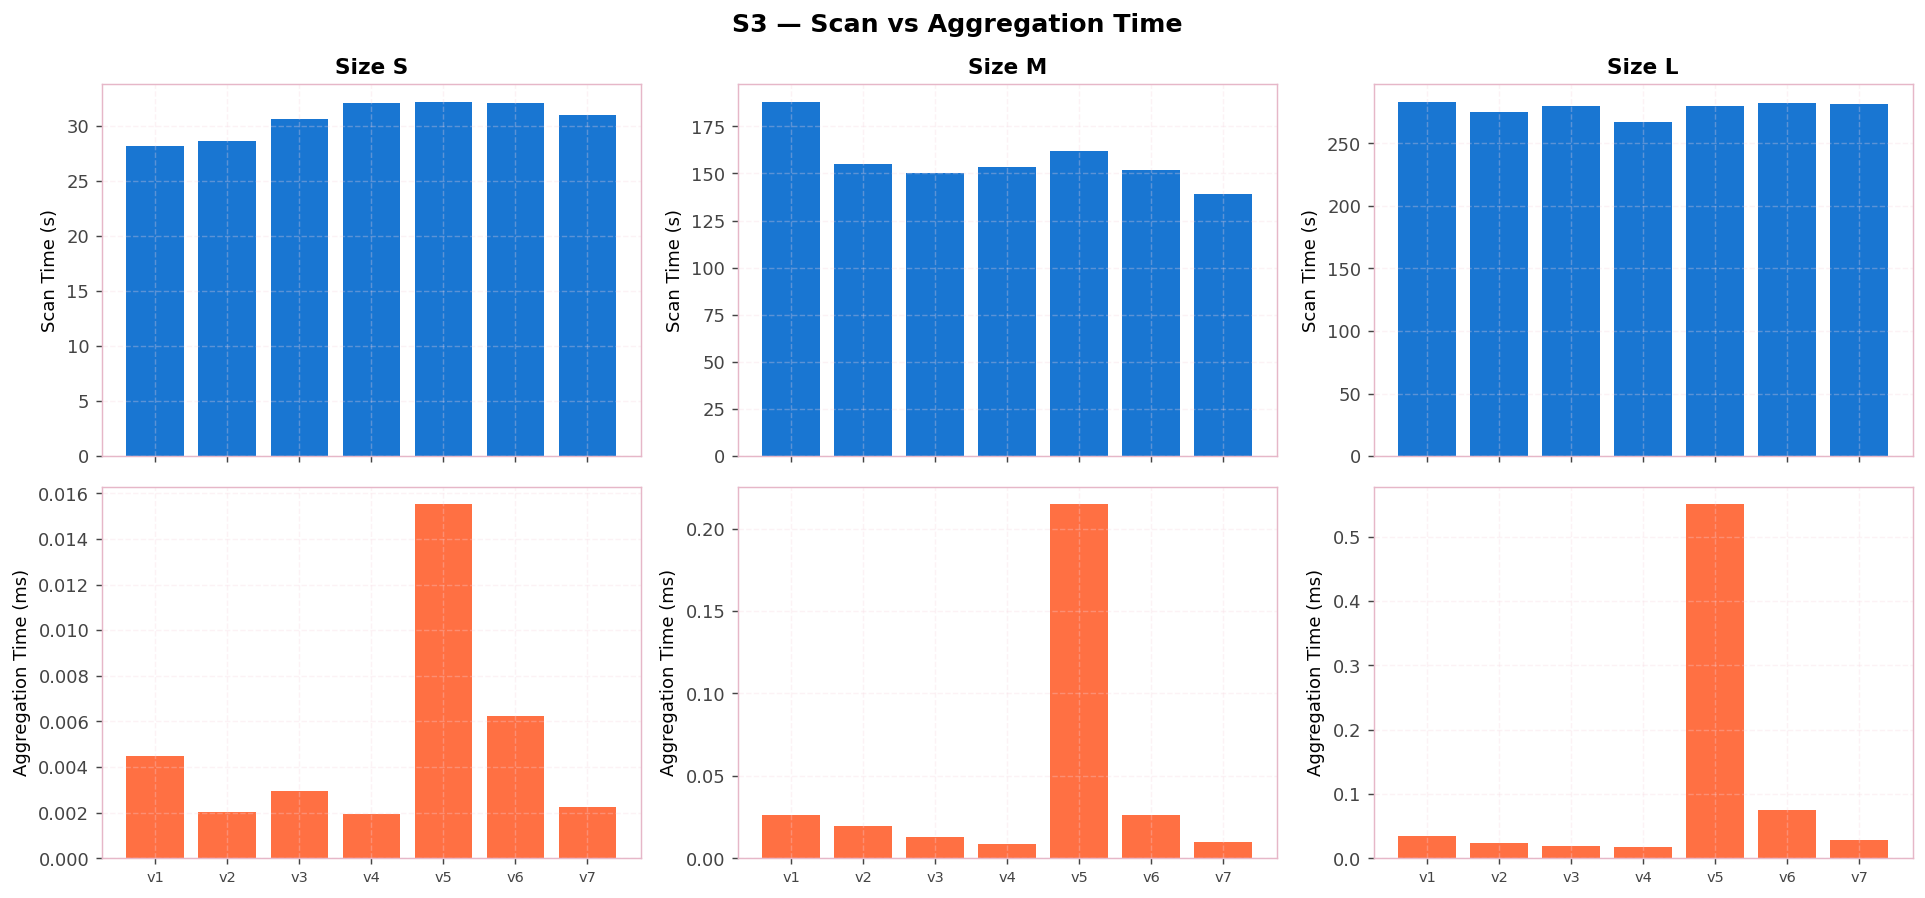

In [ ]:
# Scan vs Aggregation time split
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 7),
    sharex='col'
)

for col, size in enumerate(['S', 'M', 'L']):

    if size not in sizes_present:
        axes[0, col].set_visible(False)
        axes[1, col].set_visible(False)
        continue

    sub = (
        s3_scan[s3_scan['size_label'] == size]
        .groupby('preset')[['scan_ms', 'agg_ms']]
        .mean()
        / 1000
    )

    sub = sub.reindex(presets).dropna()

    x = np.arange(len(sub))

    # ── Top: Scan Time ───────────────────────
    axes[0, col].bar(
        x,
        sub['scan_ms'],
        color='#1976D2'
    )

    axes[0, col].set_title(
        f'Size {size}',
        fontweight='bold'
    )

    axes[0, col].set_ylabel('Scan Time (s)')

    axes[0, col].grid(
        True,
        linestyle='--',
        alpha=0.3
    )

    # ── Bottom: Aggregation Time ─────────────
    axes[1, col].bar(
        x,
        sub['agg_ms'],
        color='#FF7043'
    )

    axes[1, col].set_ylabel('Aggregation Time (s)')

    axes[1, col].set_xticks(x)
    axes[1, col].set_xticklabels(
        sub.index,
        fontsize=8
    )

    axes[1, col].grid(
        True,
        linestyle='--',
        alpha=0.3
    )

# ── Global title ────────────────────────────
fig.suptitle(
    'S3 — Scan vs Aggregation Time',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [34]:
df[['scan_ms', 'agg_ms']].describe()

,scan_ms,agg_ms
count,203.000000,203.000000
mean,241979.703179,54.423290
std,218786.681636,101.683742
min,106.380917,0.273417
25%,31452.310917,7.704271
50%,168981.652500,20.275125
75%,385473.464959,46.906000
max,903001.602500,622.353583


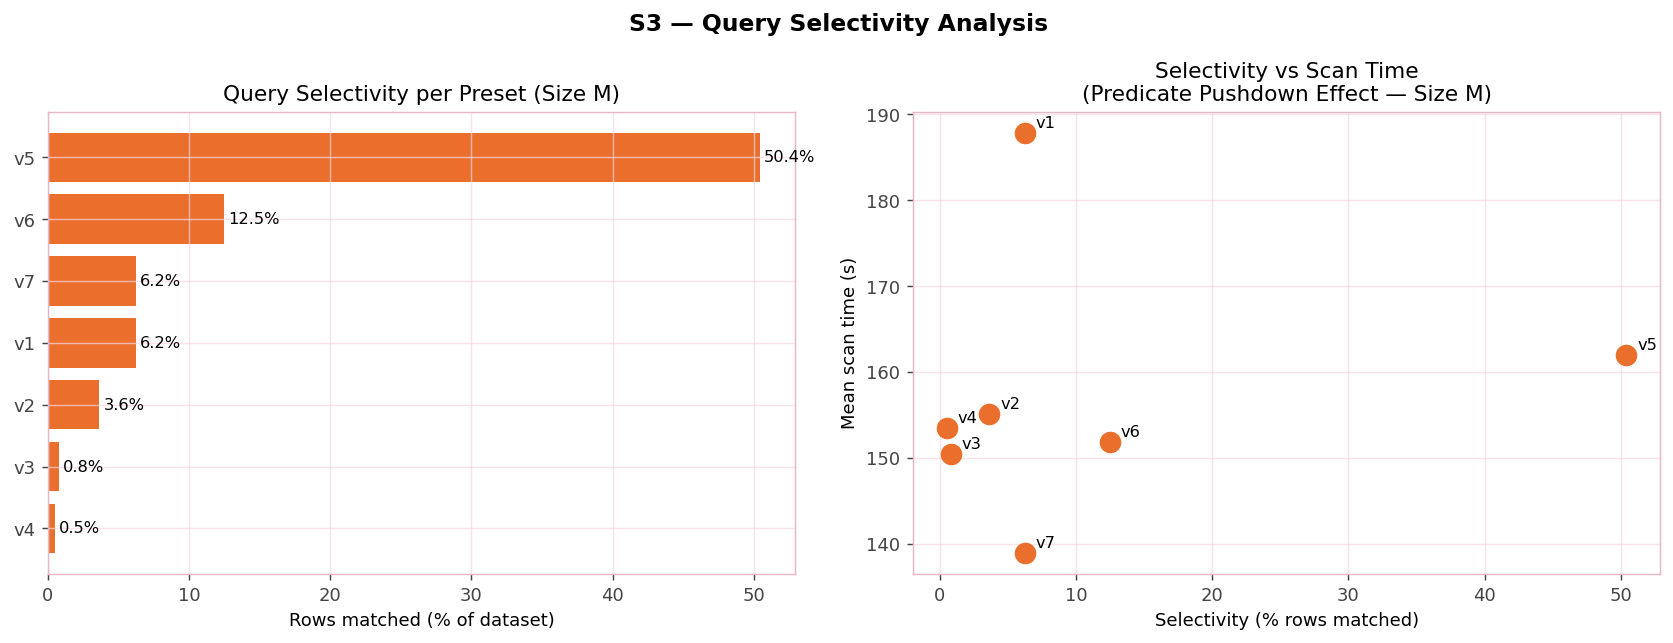

preset  selectivity_pct  mean_scan_s  rows_matched  rows_scanned
    v1             6.23   187.868306     1114572.0    17900000.0
    v2             3.64   155.068007      652316.0    17900000.0
    v3             0.78   150.450877      139798.0    17900000.0
    v4             0.52   153.516775       92902.0    17900000.0
    v5            50.41   161.935743     9023560.0    17900000.0
    v6            12.49   151.882195     2236458.0    17900000.0
    v7             6.25   138.918132     1119523.0    17900000.0


In [35]:
# Query selectivity — rows matched vs rows scanned
sel = s3_scan[s3_scan['size_label']=='M'].groupby('preset').agg(
    rows_scanned=('rows_scanned','first'),
    rows_matched=('rows_matched','mean'),
    mean_scan_ms=('scan_ms','mean'),
).reset_index()
sel['selectivity_pct'] = (sel['rows_matched'] / sel['rows_scanned'] * 100).round(2)
sel['mean_scan_s'] = sel['mean_scan_ms'] / 1000
sel_sorted = sel.sort_values('selectivity_pct')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bars = axes[0].barh(sel_sorted['preset'], sel_sorted['selectivity_pct'], color='#EA6F2D')
axes[0].set_xlabel('Rows matched (% of dataset)')
axes[0].set_title('Query Selectivity per Preset (Size M)')
for bar, (_, row) in zip(bars, sel_sorted.iterrows()):
    axes[0].text(row['selectivity_pct']+0.3, bar.get_y()+bar.get_height()/2,
                 f"{row['selectivity_pct']:.1f}%", va='center', fontsize=9)

axes[1].scatter(sel['selectivity_pct'], sel['mean_scan_s'], s=120, color="#EA6F2D", zorder=3)
for _, row in sel.iterrows():
    axes[1].annotate(row['preset'], (row['selectivity_pct'], row['mean_scan_s']),
                     textcoords='offset points', xytext=(6,3), fontsize=9)
axes[1].set_xlabel('Selectivity (% rows matched)')
axes[1].set_ylabel('Mean scan time (s)')
axes[1].set_title('Selectivity vs Scan Time\n(Predicate Pushdown Effect — Size M)')
fig.suptitle('S3 — Query Selectivity Analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(sel[['preset','selectivity_pct','mean_scan_s','rows_matched','rows_scanned']].to_string(index=False))

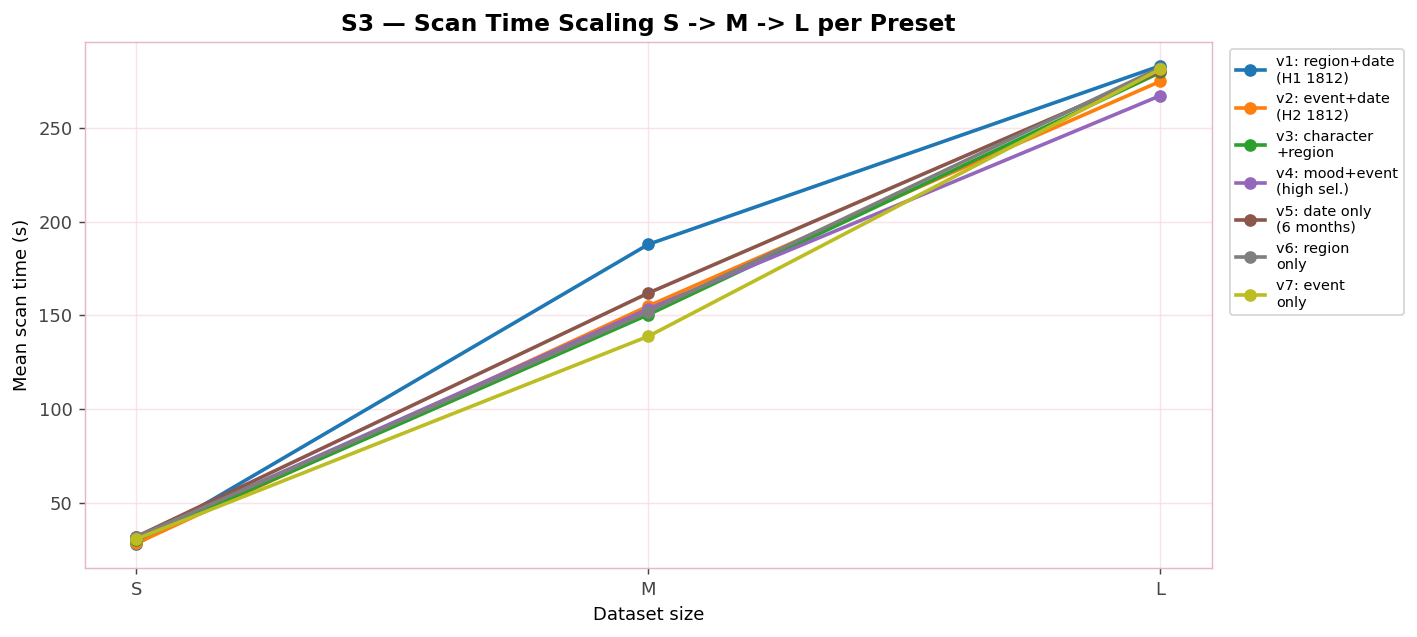

In [36]:
# Scan time scaling S -> M -> L
fig, ax = plt.subplots(figsize=(11, 5))
cmap = plt.get_cmap('tab10')

for i, preset in enumerate(presets):
    sub = (
        s3_scan[s3_scan['preset'] == preset]
        .groupby('size_label')['scan_ms']
        .mean()
        / 1000
    )

    sub = sub.reindex(SIZE_ORDER).dropna()

    if len(sub) > 0:
        ax.plot(
            sub.index.astype(str),
            sub.values,
            marker='o',
            label=f"{preset}: {PRESET_DESC.get(preset, '')}",
            color=cmap(i / len(presets)),
            linewidth=2
        )

ax.set_title(
    'S3 — Scan Time Scaling S -> M -> L per Preset',
    fontsize=13,
    fontweight='bold'
)

ax.set_ylabel('Mean scan time (s)')
ax.set_xlabel('Dataset size')

ax.legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=8
)

plt.tight_layout()
plt.show()

## 6. Publish Benchmark — Manifest-Based Publishing Overhead

The publish workflow: **validation** (read dataset, check schema + stats) then **manifest write** (`latest.json` to S3).

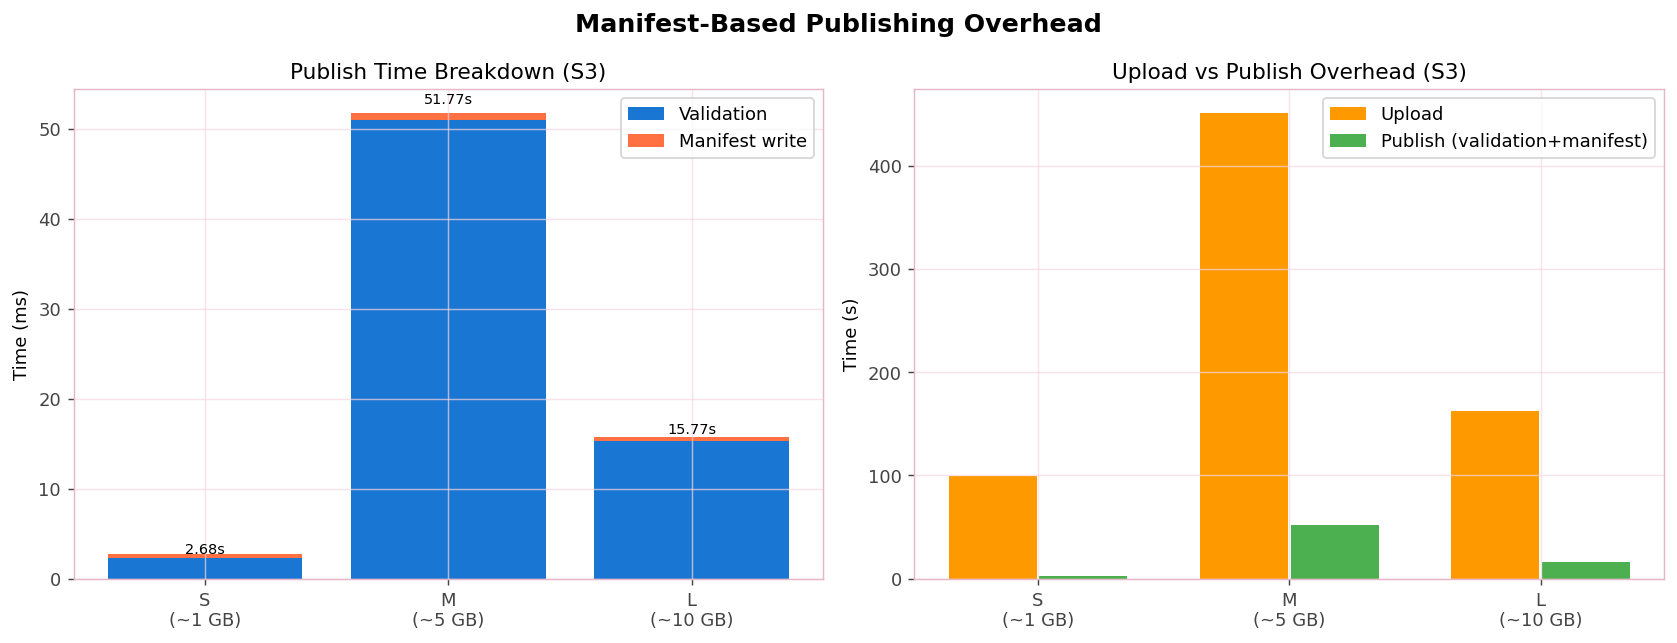

           validation_ms         metadata_ms        elapsed_ms        
                    mean     std        mean    std       mean     std
size_label                                                            
L                15236.0  1095.7       538.6   76.4    15774.5  1120.1
M                50978.6  5042.6       793.5  600.6    51772.2  5333.2
S                 2337.3   265.2       341.4   84.6     2678.7   344.1


In [ ]:
pub_df = df[(df['test_type']=='publish') & (df['backend']=='s3')]

if pub_df.empty:
    print("No publish data available yet.")
else:
    pub_agg    = pub_df.groupby('size_label')[['validation_ms','metadata_ms','elapsed_ms']].mean() / 1000
    pub_agg    = pub_agg.reindex([s for s in SIZE_ORDER if s in pub_agg.index])
    upload_agg = df[(df['test_type']=='upload') & (df['backend']=='s3')].groupby('size_label')['elapsed_ms'].mean() / 1000

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    x = np.arange(len(pub_agg))
    axes[0].bar(x, pub_agg['validation_ms'], label='Validation', color='#1976D2')
    axes[0].bar(x, pub_agg['metadata_ms'], bottom=pub_agg['validation_ms'],
                label='Manifest write', color='#FF7043')
    axes[0].set_title('Publish Time Breakdown (S3)')
    axes[0].set_ylabel('Time (s)')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([SIZE_LABELS[s] for s in pub_agg.index])
    axes[0].legend()
    for i, (s, row) in enumerate(pub_agg.iterrows()):
        axes[0].text(i, row['elapsed_ms']*1.02, f"{row['elapsed_ms']:.2f}s",
                     ha='center', fontsize=8)

    sizes_both = [s for s in SIZE_ORDER if s in pub_agg.index and s in upload_agg.index]
    x2 = np.arange(len(sizes_both))
    axes[1].bar(x2-0.18, [upload_agg[s] for s in sizes_both], 0.35,
                label='Upload', color='#FF9900')
    axes[1].bar(x2+0.18, [pub_agg.loc[s,'elapsed_ms'] for s in sizes_both], 0.35,
                label='Publish (validation+manifest)', color='#4CAF50')
    axes[1].set_title('Upload vs Publish Overhead (S3)')
    axes[1].set_ylabel('Time (s)')
    axes[1].set_xticks(x2)
    axes[1].set_xticklabels([SIZE_LABELS[s] for s in sizes_both])
    axes[1].legend()

    fig.suptitle('Manifest-Based Publishing Overhead', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

    print(pub_df.groupby('size_label')[['validation_ms','metadata_ms','elapsed_ms']]
          .agg(['mean','std']).round(1).to_string())

## 7. Azure vs S3 Comparison (Bonus)

> Azure data is partial (S and M, some presets). Plots show only available combinations and update automatically when more data is added.

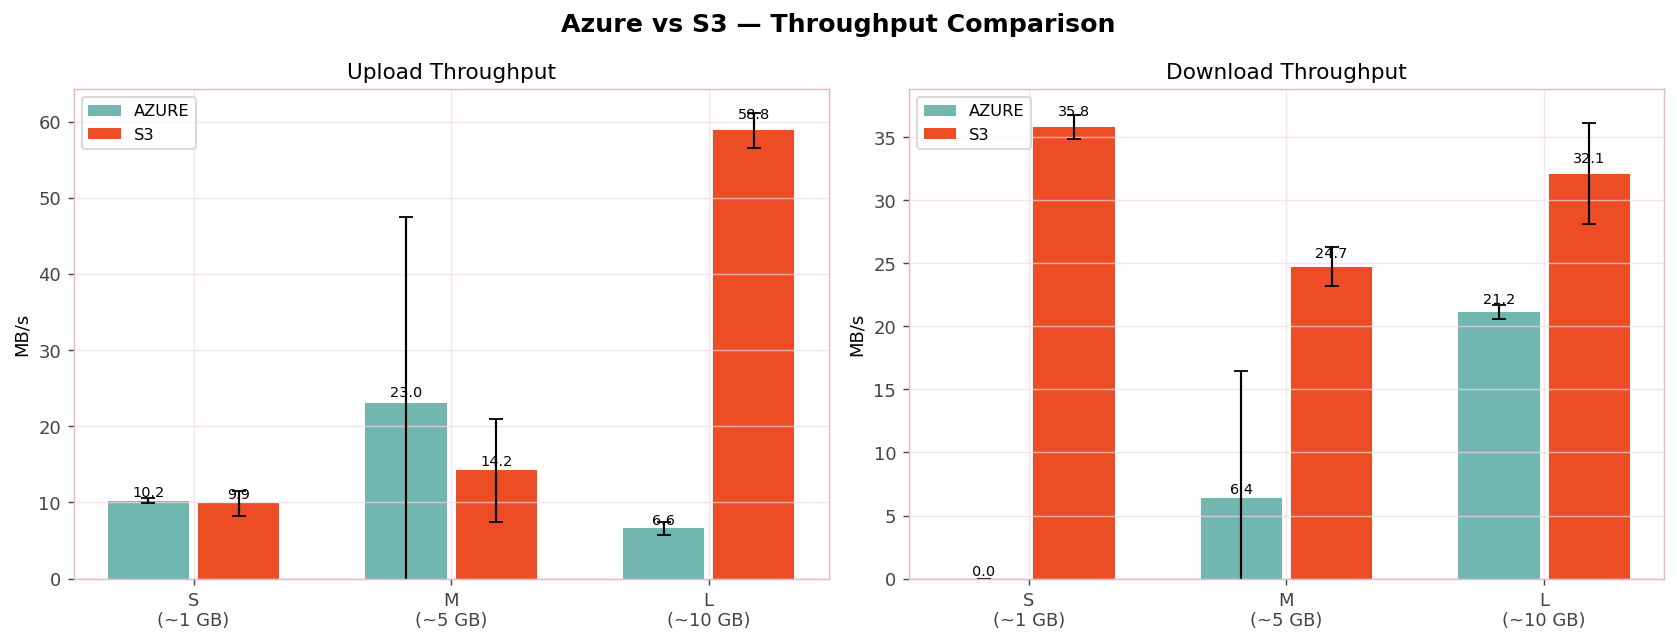

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
grouped_bars(axes[0], df, 'upload',   'throughput_mb_s', 'Upload Throughput',   'MB/s')
grouped_bars(axes[1], df, 'download', 'throughput_mb_s', 'Download Throughput', 'MB/s')
fig.suptitle('Azure vs S3 — Throughput Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

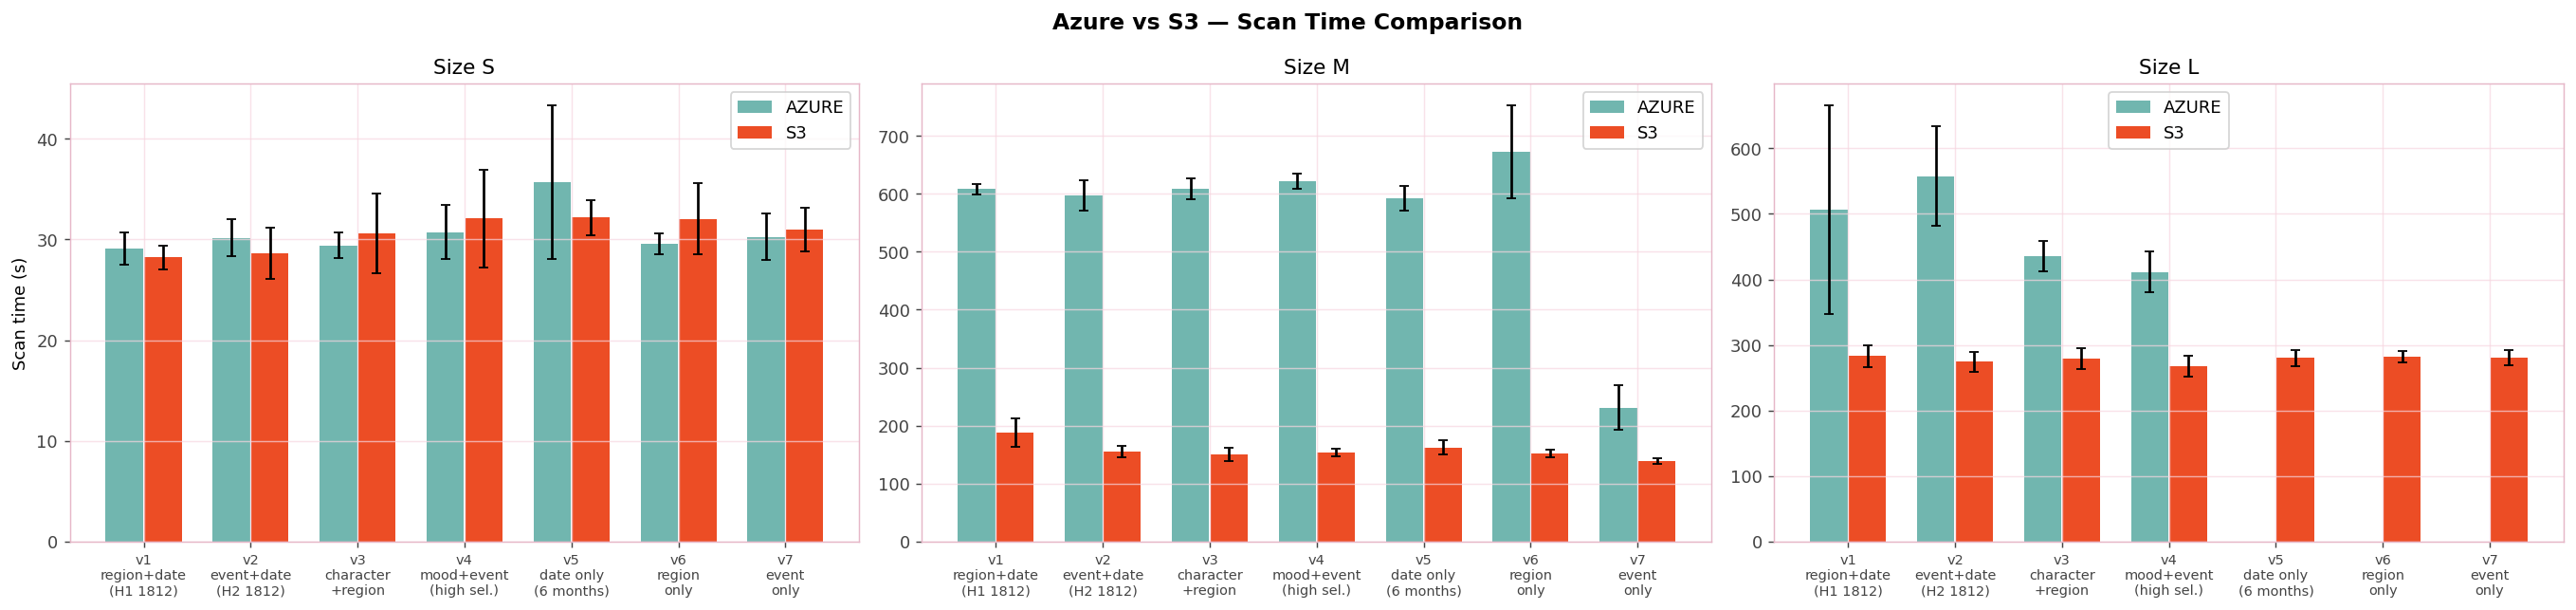

In [43]:
common_presets = sorted(
    set(scan_df[scan_df['backend']=='s3']['preset']) &
    set(scan_df[scan_df['backend']=='azure']['preset'])
)
common_sizes = [s for s in SIZE_ORDER if
    s in scan_df[scan_df['backend']=='s3']['size_label'].values and
    s in scan_df[scan_df['backend']=='azure']['size_label'].values
]

if not common_presets or not common_sizes:
    print("No overlapping scan data between backends yet.")
else:
    both = scan_df[
        scan_df['preset'].isin(common_presets) &
        scan_df['size_label'].isin(common_sizes)
    ]
    fig, axes = plt.subplots(1, len(common_sizes), figsize=(7*len(common_sizes), 5))
    if len(common_sizes) == 1: axes = [axes]

    for ax, size in zip(axes, common_sizes):
        sub = both[both['size_label']==size]
        x = np.arange(len(common_presets))
        for i, backend in enumerate(sorted(sub['backend'].unique())):
            bsub = sub[sub['backend']==backend].groupby('preset')['scan_ms'].agg(['mean','std']) / 1000
            means = [bsub.loc[p,'mean'] if p in bsub.index else np.nan for p in common_presets]
            stds  = [bsub.loc[p,'std']  if p in bsub.index else 0      for p in common_presets]
            offset = -0.18 if i==0 else 0.18
            ax.bar(x+offset, means, 0.35, label=backend.upper(),
                   color=COLORS[backend], yerr=stds, capsize=3)
        ax.set_title(f'Size {size}')
        ax.set_ylabel('Scan time (s)' if size==common_sizes[0] else '')
        ax.set_xticks(x)
        ax.set_xticklabels([f"{p}\n{PRESET_DESC.get(p,'')}" for p in common_presets], fontsize=8)
        ax.legend()

    fig.suptitle('Azure vs S3 — Scan Time Comparison', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

In [40]:
# Full summary table
df[df['test_type'].isin(['upload','download','listing'])].groupby(
    ['backend','size_label','test_type']
).agg(
    runs=('run','count'),
    mean_elapsed_ms=('elapsed_ms','mean'),
    std_elapsed_ms=('elapsed_ms','std'),
    mean_throughput_mb_s=('throughput_mb_s','mean'),
).round(2)

runs  mean_elapsed_ms  std_elapsed_ms  \
backend size_label test_type                                          
azure   L          download      5        451033.50        11408.77   
                   listing       5           124.50           95.23   
                   upload        5       1464667.60       195114.77   
        M          download     15        105225.54       147705.69   
                   listing      10           111.21           70.47   
                   upload       10         54369.23        53753.90   
        S          download      5          5819.57          245.62   
                   listing       5            67.95            5.04   
                   upload        5         93280.21         2504.83   
s3      L          download      5        301329.22        41904.41   
                   listing       5            90.46           61.78   
                   upload        5        162344.36         6434.05   
        M          download      5        193465.12        12497.67   
                   listing       5           106.86           85.87   
                   upload        5        451281.33       320026.13   
        S          download      5         26669.73          726.25   
                   listing       5            65.65            1.58   
                   upload        5         99653.69        21528.34   

                              mean_throughput_mb_s  
backend size_label test_type                        
azure   L          download                  21.17  
                   listing                     NaN  
                   upload                     6.61  
        M          download                   6.39  
                   listing                     NaN  
                   upload                    23.00  
        S          download                   0.00  
                   listing                     NaN  
                   upload                    10.24  
s3      L          download                  32.11  
                   listing                     NaN  
                   upload                    58.85  
        M          download                  24.74  
                   listing                     NaN  
                   upload                    14.22  
        S          download                  35.81  
                   listing                     NaN  
                   upload                     9.86

## 8. Key Findings & Recommendations

### Upload & Download
- S3 upload throughput scales well with dataset size: ~10 MB/s for S, ~14 MB/s for M, and ~59 MB/s for L. The anomalously high variance for S3 M (std = 320s) is caused by a single cold-start run (~990s) that stabilises to ~240s for subsequent runs, which we can say is a warm-up effect. Benchmarks should discard run 1 or use more runs for stable estimates.
- Azure upload was competitive for S and M (~10 MB/s and ~23 MB/s) but dropped to 6.6 MB/s for L, with high variance throughout.
- S3 download was consistently faster: 35.8 MB/s (S), 24.7 MB/s (M), 32.1 MB/s (L). Azure download recovered to 6.4–21.2 MB/s for M and L after fixing a bug where downloaded bytes were not written to disk.
- **Recommendation:** prefer S3 for large sequential transfers.

### Listing
- Listing time was negligible across both backends: 65–125 ms for 4–36 objects, all fitting in a single API page (list_requests = 1 everywhere).
- Azure listing was slightly slower than S3 for larger object counts (124 ms vs 90 ms for L) with higher variance.
- **Recommendation:** listing overhead is not a concern at these file counts. It would become significant with thousands of small files — prefer fewer, larger files.

### Parquet Scan & Predicate Pushdown
- Scan time scales approximately linearly with dataset size: ~30s (S), ~140–190s (M), ~265–285s (L) on S3.
- **Aggregation is negligible:** mean agg_ms = 53ms vs mean scan_ms = 217,000ms across all runs. The bottleneck is entirely network I/O, not compute.
- **Predicate pushdown has minimal effect on scan time** despite large differences in selectivity. Preset v4 (0.5% rows matched) took 154s while v5 (50.4% rows matched) took 162s — a 100× selectivity difference with only 5% time difference. This is because the data is uniformly random: row groups are not selective enough to be skipped based on min/max statistics.
- **Recommendation:** to make predicate pushdown effective, physically partition data by frequently-filtered columns (e.g. region, event_type). With partitioning, Parquet can skip entire files rather than reading and filtering everything.

### Azure vs S3 Scan
- For size S, Azure and S3 scan times were comparable (~30s each).
- For size M, Azure was 3–4× slower (600–760s vs 140–190s). For size L, Azure was ~2× slower (520s vs 283s for v1).
- Azure also required retry logic for intermittent socket timeouts during large scans.
- **Recommendation:** for PyArrow-based analytical workloads, S3 with the native S3FileSystem is significantly faster than Azure via adlfs at M and L scales.

### Manifest-Based Publishing
- Validation dominated publish time in all cases: 2.3s (S), 51.0s (M), 15.2s (L). Manifest write was always fast: 341ms (S), 794ms (M), 539ms (L).
- Publish overhead relative to upload: ~3% for S, ~11% for M, ~10% for L — small and bounded.
- The non-monotonic validation time (M > L) reflects per-file request overhead dominating over data volume, since validation reads only 4 columns.
- **Recommendation:** manifest-based publishing is a practical approach to safe dataset versioning. The consistency guarantee (readers always see a complete, validated version) costs less than 11% of upload time at all tested scales.

### Limitations
- All data is synthetically generated with uniform random distributions — real workloads with skew or temporal locality would behave differently.
- File transfers are sequential; parallel transfer would significantly improve throughput.
- No concurrent writers were tested — race conditions between writers in the manifest workflow were not evaluated.
- Azure results are incomplete (missing some presets and sizes) due to connection instability.